# Coupling Test: Statistics and Figures

This notebook reads outputs generated by the coupling analysis script and produces:

1. Histograms of coupling gain at the dyad, therapist, and client levels.
2. Scatter plots of coupling benefit per session and per transition.
3. Basic significance checks for positive coupling effects.

In [1]:
from pathlib import Path
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from scipy.stats import binomtest, pearsonr, spearmanr, wilcoxon

# Match legacy plotting style for comparability
mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "Serif"],
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# Resolve project root for notebook 
if (os.environ.get("PROJECT_ROOT")):
    project_root = Path(os.environ["PROJECT_ROOT"]).resolve()
else:
    project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

cfg_path = project_root / "configs" / "analysis.yaml"
cfg = yaml.safe_load(cfg_path.read_text())
out_dir = project_root / cfg["analysis"]["out_dir"]
out_dir.mkdir(parents=True, exist_ok=True)

# Expected outputs from scripts/02_run_coupling.py
coupling_session_csv = out_dir / "coupling_results.csv"
coupling_dyad_csv = out_dir / "coupling_by_dyad.csv"
directionality_dyad_csv = out_dir / "directionality_by_dyad.csv"

coupling_session = pd.read_csv(coupling_session_csv)
coupling_dyad = pd.read_csv(coupling_dyad_csv)
directionality_dyad = pd.read_csv(directionality_dyad_csv)

print("Loaded:")
print(f"- {coupling_session_csv} ({len(coupling_session)} rows)")
print(f"- {coupling_dyad_csv} ({len(coupling_dyad)} rows)")
print(f"- {directionality_dyad_csv} ({len(directionality_dyad)} rows)")


Loaded:
- /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/coupling_results.csv (108 rows)
- /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/coupling_by_dyad.csv (80 rows)
- /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/directionality_by_dyad.csv (80 rows)


## 1) Coupling Gain Histograms

These histograms summarize three levels of coupling benefit:

- **Dyad-level gain**: weighted mean gain per transition for each dyad.
- **Therapist direction gain**: dyad-level weighted gain for client → therapist prediction improvement.
- **Client direction gain**: dyad-level weighted gain for therapist → client prediction improvement.

A value above zero indicates better predictive performance from the coupled model versus the independent model.

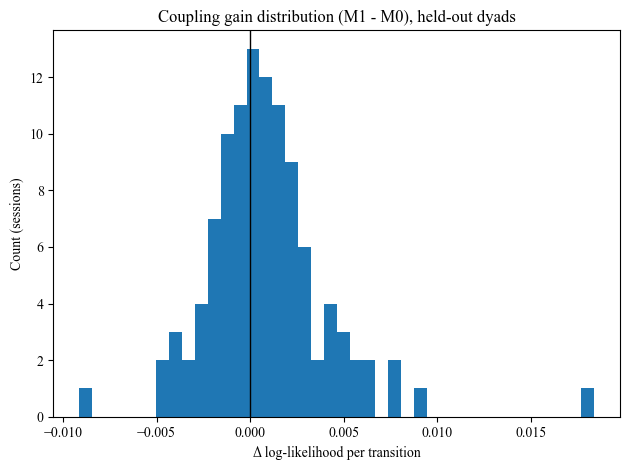

Saved: /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/coupling_gain_hist_replicated.svg


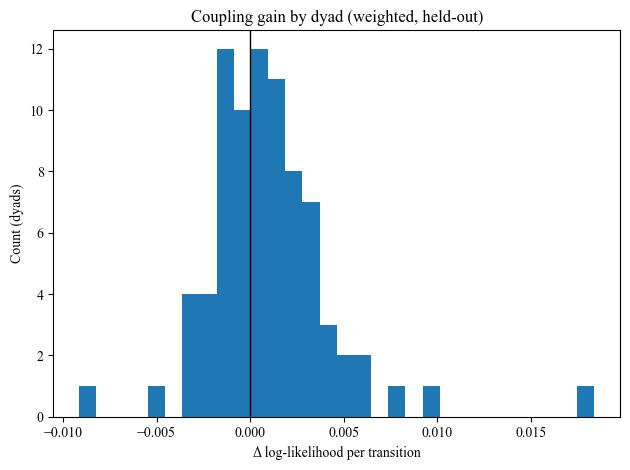

Saved: /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/coupling_gain_by_dyad_hist_replicated.svg


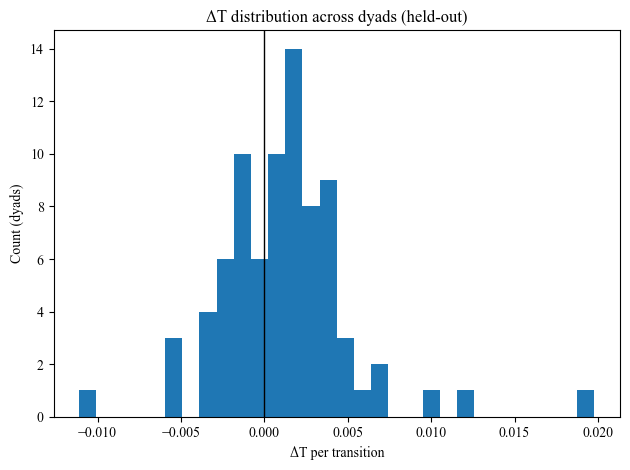

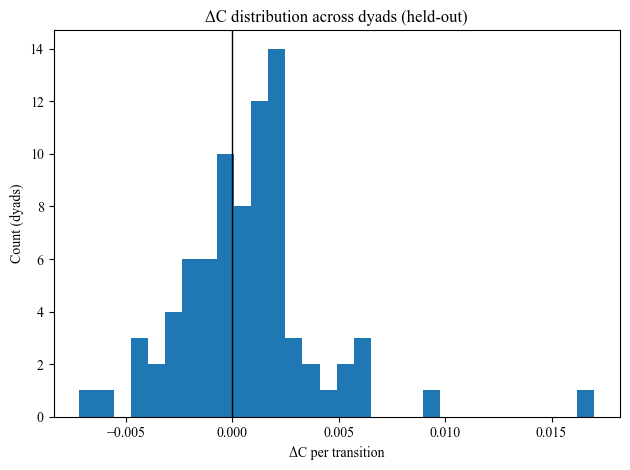

Saved: /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/influence_hist_T.svg and /Users/cartersale/Research/projects/therapy_dynamics/Affect-Dynamics/artifacts/influence_hist_C.svg


In [2]:
# Match legacy 'coupling_gain_hist.svg' (Session-level gain distribution)
session_gain = coupling_session["gain_per_trans"].to_numpy(dtype=float)

plt.figure()
plt.hist(session_gain[np.isfinite(session_gain)], bins=40)
plt.axvline(0.0, color="black", lw=1.0)
plt.title("Coupling gain distribution (M1 - M0), held-out dyads")
plt.xlabel("Δ log-likelihood per transition")
plt.ylabel("Count (sessions)")
plt.tight_layout()
plt.savefig(out_dir / "coupling_gain_hist_replicated.svg", dpi=200)
plt.show()
print(f"Saved: {out_dir / 'coupling_gain_hist_replicated.svg'}")

# Dyad-level histograms (matches triptych logic but clearer separation)
dyad_gain = coupling_dyad["gain_per_trans_wmean"].to_numpy(dtype=float)
# Define these for later significance checks
therapist_gain = directionality_dyad["dT_per_trans_wmean"].to_numpy(dtype=float)
client_gain = directionality_dyad["dC_per_trans_wmean"].to_numpy(dtype=float)

plt.figure()
plt.hist(dyad_gain[np.isfinite(dyad_gain)], bins=30)
plt.axvline(0.0, color="black", lw=1.0)
plt.title("Coupling gain by dyad (weighted, held-out)")
plt.xlabel("Δ log-likelihood per transition")
plt.ylabel("Count (dyads)")
plt.tight_layout()
plt.savefig(out_dir / "coupling_gain_by_dyad_hist_replicated.svg", dpi=200)
plt.show()
print(f"Saved: {out_dir / 'coupling_gain_by_dyad_hist_replicated.svg'}")

# Generate influence histograms for T/C as well (matches 03c_directionality.py histograms)
plt.figure()
plt.hist(therapist_gain[np.isfinite(therapist_gain)], bins=30)
plt.axvline(0.0, color="black", lw=1.0)
plt.title("ΔT distribution across dyads (held-out)")
plt.xlabel("ΔT per transition")
plt.ylabel("Count (dyads)")
plt.tight_layout()
plt.savefig(out_dir / "influence_hist_T.svg", dpi=200)
plt.show()

plt.figure()
plt.hist(client_gain[np.isfinite(client_gain)], bins=30)
plt.axvline(0.0, color="black", lw=1.0)
plt.title("ΔC distribution across dyads (held-out)")
plt.xlabel("ΔC per transition")
plt.ylabel("Count (dyads)")
plt.tight_layout()
plt.savefig(out_dir / "influence_hist_C.svg", dpi=200)
plt.show()
print(f"Saved: {out_dir / 'influence_hist_T.svg'} and {out_dir / 'influence_hist_C.svg'}")


## 2) Coupling Benefit Scatter Plots

This section shows coupling benefit in two ways:

- **Per session**: total gain $\Delta LL = LL_{M1} - LL_{M0}$, colored by number of transitions.
- **Per transition**: normalized gain $\Delta LL / n_{transitions}$ against transition count.

The colorbar in the first plot highlights how much data supports each session estimate.

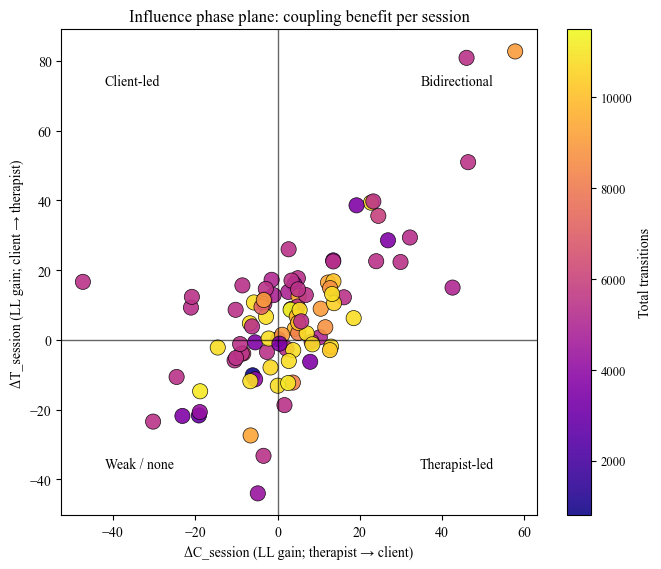

Saved: /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/influence_phase_plane_replicated.svg


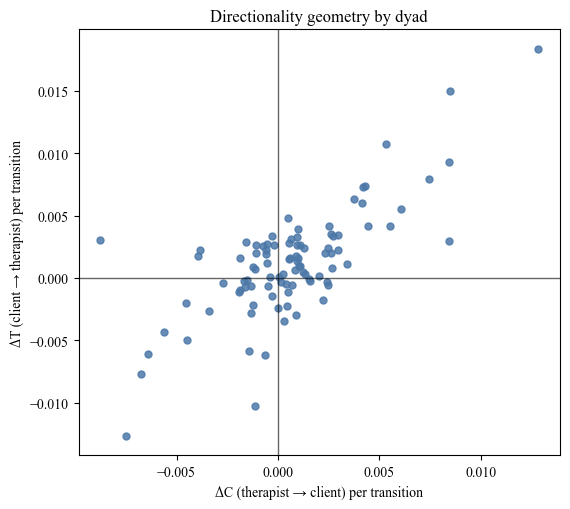

Saved: /Users/cartersale/Research/Projects/Affect-Dynamics/artifacts/influence_scatter_by_dyad_replicated.svg


In [14]:
# Load directionality results (dyad-level aggregation)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

directionality_dyad_csv = out_dir / "directionality_by_dyad.csv"
if not directionality_dyad_csv.exists():
    print(f"[ERROR] {directionality_dyad_csv} not found. Run analysis script with directionality enabled.")
else:
    dy = pd.read_csv(directionality_dyad_csv)
    
    # Ensure consistent column names across analysis scripts
    if "avg_trans_per_session" in dy.columns:
        avg_trans = dy["avg_trans_per_session"].to_numpy(dtype=float)
    elif {"n_transitions", "n_samples"}.issubset(dy.columns):
        avg_trans = (dy["n_transitions"] / dy["n_samples"].replace(0, np.nan)).to_numpy(dtype=float)
    else:
        avg_trans = np.full(len(dy), np.nan, dtype=float)

    # Per-session gains: (per-transition gain) x (avg transitions per session)
    x_sess = dy["dC_wmean"].to_numpy(dtype=float) * avg_trans
    y_sess = dy["dT_wmean"].to_numpy(dtype=float) * avg_trans

    # Color encodes total transitions observed for each dyad
    colors = dy["n_transitions"].to_numpy(dtype=float) if "n_transitions" in dy.columns else np.nan_to_num(avg_trans, nan=0.0)
    colors = np.nan_to_num(colors, nan=0.0)

    # Marker size optionally encodes a dyad-level entropy metric if present; otherwise constant size
    if "regime_entropy" in dy.columns:
        ent = dy["regime_entropy"].to_numpy(dtype=float)
        fin = ent[np.isfinite(ent)]
        if fin.size:
            emin, emax = fin.min(), fin.max()
            denom = (emax - emin) if (emax - emin) > 1e-9 else 1.0
            norm = np.nan_to_num((ent - emin) / denom, nan=0.0)
            sizes = 80.0 + 320.0 * norm
        else:
            sizes = np.full(len(dy), 120.0, dtype=float)
    else:
        sizes = np.full(len(dy), 120.0, dtype=float)

    # Plot 1: Influence phase plane (per-session gains)
    plt.figure(figsize=(6.8, 5.8))

    sc = plt.scatter(
        x_sess,
        y_sess,
        c=colors,
        s=sizes,
        cmap="plasma",
        edgecolor="k",
        linewidths=0.5,
        alpha=0.9,
    )

    cbar = plt.colorbar(sc, label="Total transitions")
    cbar.ax.tick_params(labelsize=9)

    plt.axvline(0.0, color="k", lw=1.0, alpha=0.6)
    plt.axhline(0.0, color="k", lw=1.0, alpha=0.6)
    plt.xlabel("ΔC_session (LL gain; therapist → client)")
    plt.ylabel("ΔT_session (LL gain; client → therapist)")
    plt.title("Influence phase plane: coupling benefit per session")

    # Quadrant labels placed relative to the data range
    finite_x = x_sess[np.isfinite(x_sess)]
    finite_y = y_sess[np.isfinite(y_sess)]
    xmin, xmax = (finite_x.min(), finite_x.max()) if finite_x.size else (-1.0, 1.0)
    ymin, ymax = (finite_y.min(), finite_y.max()) if finite_y.size else (-1.0, 1.0)
    pad_x = 0.05 * (xmax - xmin if (xmax - xmin) > 0 else 1.0)
    pad_y = 0.05 * (ymax - ymin if (ymax - ymin) > 0 else 1.0)

    plt.text(max(0.0, xmax) - pad_x, max(0.0, ymax) - pad_y, "Bidirectional", ha="right", va="top")
    plt.text(min(0.0, xmin) + pad_x, max(0.0, ymax) - pad_y, "Client-led", ha="left", va="top")
    plt.text(min(0.0, xmin) + pad_x, min(0.0, ymin) + pad_y, "Weak / none", ha="left", va="bottom")
    plt.text(max(0.0, xmax) - pad_x, min(0.0, ymin) + pad_y, "Therapist-led", ha="right", va="bottom")

    plt.tight_layout()
    plt.savefig(out_dir / "influence_phase_plane_replicated.svg", dpi=200)
    plt.show()
    print(f"Saved: {out_dir / 'influence_phase_plane_replicated.svg'}")

    # Plot 2: Per-transition directionality geometry (same axis convention as Plot 1)
    plt.figure(figsize=(5.8, 5.2))
    plt.scatter(
        dy["dC_wmean"].to_numpy(dtype=float),
        dy["dT_wmean"].to_numpy(dtype=float),
        s=25,
        alpha=0.85,
        color="#4C78A8",
    )
    plt.axvline(0.0, color="k", lw=1.0, alpha=0.6)
    plt.axhline(0.0, color="k", lw=1.0, alpha=0.6)
    plt.title("Directionality geometry by dyad")
    plt.xlabel("ΔC (therapist → client) per transition")
    plt.ylabel("ΔT (client → therapist) per transition")
    plt.tight_layout()
    plt.savefig(out_dir / "influence_scatter_by_dyad_replicated.svg", dpi=200)
    plt.show()
    print(f"Saved: {out_dir / 'influence_scatter_by_dyad_replicated.svg'}")


## 3) Quick Significance Checks

We run simple one-sided tests to assess whether coupling gains are generally positive:

- **Wilcoxon signed-rank** test for median gain $> 0$.
- **Binomial sign test** for fraction of positive gains $> 0.5$.

These checks are reported separately for dyad-level, therapist-direction, and client-direction gains.

In [3]:
def summarize_positive_effect(x: np.ndarray, label: str) -> None:
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        print(f"{label}: no valid values")
        return

    n = x.size
    n_pos = int((x > 0).sum())
    frac_pos = n_pos / n

    w = wilcoxon(x, alternative="greater", zero_method="wilcox")
    b = binomtest(n_pos, n, p=0.5, alternative="greater")

    print(f"\n{label}")
    print(f"  N = {n}")
    print(f"  Mean = {float(np.mean(x)):.6g}")
    print(f"  Median = {float(np.median(x)):.6g}")
    print(f"  Positive = {n_pos}/{n} ({100*frac_pos:.1f}%)")
    print(f"  Wilcoxon p (median > 0) = {w.pvalue:.4g}")
    print(f"  Binomial p (frac > 0.5) = {b.pvalue:.4g}")


summarize_positive_effect(dyad_gain, "Dyad-level coupling gain")
summarize_positive_effect(therapist_gain, "Therapist-direction gain (ΔT)")
summarize_positive_effect(client_gain, "Client-direction gain (ΔC)")

# Correlation between therapist and client directional gains (dyad-level)
valid_pair = np.isfinite(therapist_gain) & np.isfinite(client_gain)
t = therapist_gain[valid_pair]
c = client_gain[valid_pair]

print("\nDirectional gain association (therapist vs client)")
if t.size < 3:
    print("  Not enough paired dyads for correlation test.")
else:
    r_pearson, p_pearson = pearsonr(t, c)
    r_spearman, p_spearman = spearmanr(t, c)
    print(f"  N paired dyads = {t.size}")
    print(f"  Pearson r = {r_pearson:.4g}, p = {p_pearson:.4g}")
    print(f"  Spearman ρ = {r_spearman:.4g}, p = {p_spearman:.4g}")

# Asymmetry term: therapist-direction minus client-direction gain
asym = t - c
print("\nAsymmetry test (ΔT - ΔC)")
if asym.size == 0:
    print("  No valid paired values.")
else:
    print(f"  Mean asymmetry = {float(np.mean(asym)):.6g}")
    print(f"  Median asymmetry = {float(np.median(asym)):.6g}")
    try:
        w_asym_2s = wilcoxon(asym, alternative="two-sided", zero_method="wilcox")
        w_asym_gt = wilcoxon(asym, alternative="greater", zero_method="wilcox")
        print(f"  Wilcoxon p (median asymmetry ≠ 0) = {w_asym_2s.pvalue:.4g}")
        print(f"  Wilcoxon p (median asymmetry > 0) = {w_asym_gt.pvalue:.4g}")
    except ValueError as exc:
        print(f"  Wilcoxon asymmetry test unavailable: {exc}")


Dyad-level coupling gain
  N = 80
  Mean = 0.000951601
  Median = 0.000647106
  Positive = 49/80 (61.3%)
  Wilcoxon p (median > 0) = 0.007415
  Binomial p (frac > 0.5) = 0.02833

Therapist-direction gain (ΔT)
  N = 80
  Mean = 0.00118972
  Median = 0.00116424
  Positive = 53/80 (66.2%)
  Wilcoxon p (median > 0) = 0.002703
  Binomial p (frac > 0.5) = 0.002434

Client-direction gain (ΔC)
  N = 80
  Mean = 0.000713483
  Median = 0.000740504
  Positive = 47/80 (58.8%)
  Wilcoxon p (median > 0) = 0.02876
  Binomial p (frac > 0.5) = 0.07282

Directional gain association (therapist vs client)
  N paired dyads = 80
  Pearson r = 0.6941, p = 9.412e-13
  Spearman ρ = 0.5407, p = 2.25e-07

Asymmetry test (ΔT - ΔC)
  Mean asymmetry = 0.000476235
  Median asymmetry = 0.000505001
  Wilcoxon p (median asymmetry ≠ 0) = 0.1529
  Wilcoxon p (median asymmetry > 0) = 0.07646


## 4) Coupling Test with therapist-grouped 5-fold CV as a robustness check

In [3]:
# Robustness check: therapist-grouped 5-fold CV outputs

robust_suffix = "_therapist_grouped_cv"
robust_coupling_dyad_csv = out_dir / f"coupling_by_dyad{robust_suffix}.csv"
robust_directionality_dyad_csv = out_dir / f"directionality_by_dyad{robust_suffix}.csv"

missing = [
    str(p) for p in [robust_coupling_dyad_csv, robust_directionality_dyad_csv] if not p.exists()
]
if missing:
    print("[ERROR] Missing therapist-grouped CV files. Run scripts/02_coupling_test.py with:")
    print("  analysis.run_therapist_grouped_cv: true")
    print("Missing:")
    for m in missing:
        print(f"  - {m}")
else:
    robust_coupling_dyad = pd.read_csv(robust_coupling_dyad_csv)
    robust_directionality_dyad = pd.read_csv(robust_directionality_dyad_csv)

    robust_dyad_gain = robust_coupling_dyad["gain_per_trans_wmean"].to_numpy(dtype=float)
    robust_therapist_gain = robust_directionality_dyad["dT_per_trans_wmean"].to_numpy(dtype=float)
    robust_client_gain = robust_directionality_dyad["dC_per_trans_wmean"].to_numpy(dtype=float)

    print("Loaded therapist-grouped robustness outputs:")
    print(f"- {robust_coupling_dyad_csv} ({len(robust_coupling_dyad)} rows)")
    print(f"- {robust_directionality_dyad_csv} ({len(robust_directionality_dyad)} rows)")

    def summarize_positive_effect_robust(x: np.ndarray, label: str) -> None:
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size == 0:
            print(f"{label}: no valid values")
            return

        n = x.size
        n_pos = int((x > 0).sum())
        frac_pos = n_pos / n

        w = wilcoxon(x, alternative="greater", zero_method="wilcox")
        b = binomtest(n_pos, n, p=0.5, alternative="greater")

        print(f"\n{label}")
        print(f"  N = {n}")
        print(f"  Mean = {float(np.mean(x)):.6g}")
        print(f"  Median = {float(np.median(x)):.6g}")
        print(f"  Positive = {n_pos}/{n} ({100*frac_pos:.1f}%)")
        print(f"  Wilcoxon p (median > 0) = {w.pvalue:.4g}")
        print(f"  Binomial p (frac > 0.5) = {b.pvalue:.4g}")

    print("\nRobustness checks with therapist-grouped 5-fold CV")
    summarize_positive_effect_robust(robust_dyad_gain, "Dyad-level coupling gain")
    summarize_positive_effect_robust(robust_therapist_gain, "Therapist-direction gain (ΔT)")
    summarize_positive_effect_robust(robust_client_gain, "Client-direction gain (ΔC)")


Loaded therapist-grouped robustness outputs:
- /Users/cartersale/Research/Projects/TherapyData/Affect-Dynamics/artifacts/coupling_by_dyad_therapist_grouped_cv.csv (95 rows)
- /Users/cartersale/Research/Projects/TherapyData/Affect-Dynamics/artifacts/directionality_by_dyad_therapist_grouped_cv.csv (95 rows)

Robustness checks with therapist-grouped 5-fold CV

Dyad-level coupling gain
  N = 95
  Mean = 0.000782366
  Median = 0.000648026
  Positive = 58/95 (61.1%)
  Wilcoxon p (median > 0) = 0.01297
  Binomial p (frac > 0.5) = 0.0198

Therapist-direction gain (ΔT)
  N = 95
  Mean = 0.00106368
  Median = 0.000845379
  Positive = 60/95 (63.2%)
  Wilcoxon p (median > 0) = 0.001743
  Binomial p (frac > 0.5) = 0.006689

Client-direction gain (ΔC)
  N = 95
  Mean = 0.000501055
  Median = 0.000388502
  Positive = 57/95 (60.0%)
  Wilcoxon p (median > 0) = 0.0516
  Binomial p (frac > 0.5) = 0.03211
